<a href="https://colab.research.google.com/github/felimaker/IBM-Data-Science-Capstone/blob/main/7_predictive_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 7: Análisis Predictivo (Machine Learning)
**Proyecto:** Predicción de aterrizaje de la primera etapa del Falcon 9

**Objetivo:** Entrenar y comparar varios modelos de clasificación para predecir si
la primera etapa del Falcon 9 aterrizará exitosamente (`Class` = 1) o no (`Class` = 0),
usando búsqueda de hiperparámetros (`GridSearchCV`) y seleccionar el mejor modelo
según su exactitud (accuracy) sobre el conjunto de prueba.

Modelos evaluados: **Regresión Logística, SVM, Árbol de Decisión y KNN.**

Repositorio de GitHub: **https://github.com/felimaker/IBM-Data-Science-Capstone**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


## 1. Cargar datos: variable objetivo (Y) y features codificadas (X)

In [3]:
# Cargamos los archivos directamente desde las URLs de respaldo del curso
url_part_2 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
url_part_3 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv"

df = pd.read_csv(url_part_2)
X = pd.read_csv(url_part_3)  # features con one-hot encoding

Y = df['Class'].to_numpy()

print("X shape:", X.shape)
print("Y shape:", Y.shape)


X shape: (90, 83)
Y shape: (90,)


## 2. Estandarizar features y dividir en train/test (80/20)

In [4]:
transform = StandardScaler()
X = transform.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2)

print("Train:", X_train.shape, "  Test:", X_test.shape)
print("Tasa de éxito en test:", Y_test.mean())


Train: (72, 83)   Test: (18, 83)
Tasa de éxito en test: 0.6666666666666666


## 3. Función auxiliar: matriz de confusión


In [9]:
def plot_confusion_matrix(y, y_predict, model_name):
    cm = confusion_matrix(y, y_predict)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fallo', 'Éxito'], yticklabels=['Fallo', 'Éxito'])
    plt.xlabel('Etiqueta predicha')
    plt.ylabel('Etiqueta real')
    plt.title(f'Matriz de confusión — {model_name}')
    plt.savefig(f'confusion_matrix_{model_name.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()


## 4. Modelo 1: Regresión Logística
Búsqueda de hiperparámetros con `GridSearchCV` (5-fold cross-validation).


Mejores hiperparámetros: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Mejor accuracy en validación cruzada: 0.8342857142857143
Accuracy en test: 0.8333333333333334


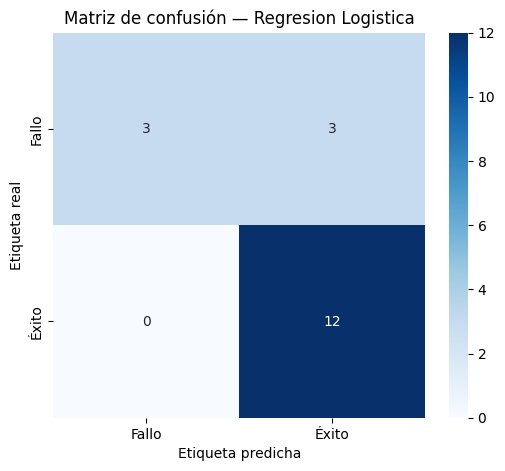

In [10]:
parameters_lr = {'C': [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}
lr = LogisticRegression()
logreg_cv = GridSearchCV(lr, parameters_lr, cv=5)
logreg_cv.fit(X_train, Y_train)

print("Mejores hiperparámetros:", logreg_cv.best_params_)
print("Mejor accuracy en validación cruzada:", logreg_cv.best_score_)

acc_lr = logreg_cv.score(X_test, Y_test)
print("Accuracy en test:", acc_lr)

yhat_lr = logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat_lr, "Regresion Logistica")


## 5. Modelo 2: Support Vector Machine (SVM)

Mejores hiperparámetros: {'C': np.float64(0.03162277660168379), 'gamma': np.float64(0.001), 'kernel': 'linear'}
Mejor accuracy en validación cruzada: 0.8342857142857142
Accuracy en test: 0.8333333333333334


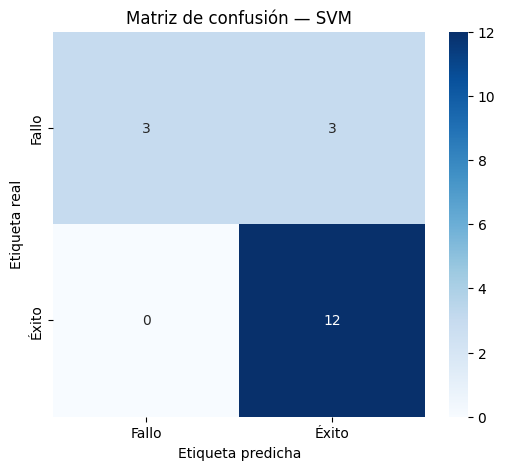

In [11]:
parameters_svm = {
    'kernel': ('linear', 'rbf', 'poly', 'sigmoid'),
    'C': np.logspace(-3, 3, 5),
    'gamma': np.logspace(-3, 3, 5)
}
svm = SVC()
svm_cv = GridSearchCV(svm, parameters_svm, cv=5)
svm_cv.fit(X_train, Y_train)

print("Mejores hiperparámetros:", svm_cv.best_params_)
print("Mejor accuracy en validación cruzada:", svm_cv.best_score_)

acc_svm = svm_cv.score(X_test, Y_test)
print("Accuracy en test:", acc_svm)

yhat_svm = svm_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat_svm, "SVM")


## 6. Modelo 3: Árbol de Decisión

Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'splitter': 'best'}
Mejor accuracy en validación cruzada: 0.8885714285714286
Accuracy en test: 0.8333333333333334


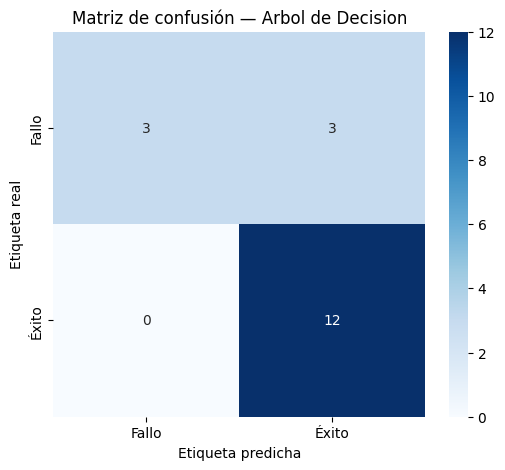

In [12]:
parameters_tree = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [2 * n for n in range(1, 10)],
    'max_features': ['sqrt'],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}
tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree, parameters_tree, cv=5)
tree_cv.fit(X_train, Y_train)

print("Mejores hiperparámetros:", tree_cv.best_params_)
print("Mejor accuracy en validación cruzada:", tree_cv.best_score_)

acc_tree = tree_cv.score(X_test, Y_test)
print("Accuracy en test:", acc_tree)

yhat_tree = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat_tree, "Arbol de Decision")


## 7. Modelo 4: K-Nearest Neighbors (KNN)

Mejores hiperparámetros: {'algorithm': 'auto', 'n_neighbors': 8, 'p': 1}
Mejor accuracy en validación cruzada: 0.8609523809523811
Accuracy en test: 0.8333333333333334


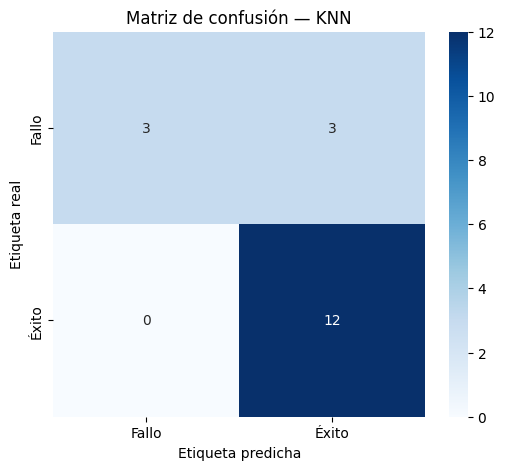

In [13]:
parameters_knn = {
    'n_neighbors': list(range(1, 11)),
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]
}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, parameters_knn, cv=5)
knn_cv.fit(X_train, Y_train)

print("Mejores hiperparámetros:", knn_cv.best_params_)
print("Mejor accuracy en validación cruzada:", knn_cv.best_score_)

acc_knn = knn_cv.score(X_test, Y_test)
print("Accuracy en test:", acc_knn)

yhat_knn = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat_knn, "KNN")


## 8. Comparación final de modelos

In [14]:
results = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'SVM', 'Árbol de Decisión', 'KNN'],
    'CV Accuracy': [logreg_cv.best_score_, svm_cv.best_score_,
                     tree_cv.best_score_, knn_cv.best_score_],
    'Test Accuracy': [acc_lr, acc_svm, acc_tree, acc_knn]
}).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

results


,Modelo,CV Accuracy,Test Accuracy
0,Regresión Logística,0.834286,0.833333
1,SVM,0.834286,0.833333
2,Árbol de Decisión,0.888571,0.833333
3,KNN,0.860952,0.833333


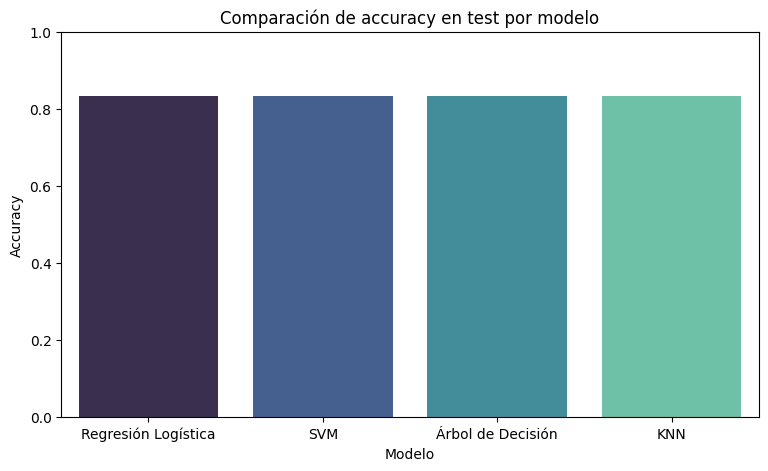

Mejor modelo: Regresión Logística (accuracy en test: 0.833)


In [16]:
plt.figure(figsize=(9, 5))
# Agregamos hue='Modelo' y legend=False para evitar la advertencia de Seaborn
sns.barplot(data=results, x='Modelo', y='Test Accuracy', palette='mako', hue='Modelo', legend=False)
plt.ylim(0, 1)
plt.title('Comparación de accuracy en test por modelo')
plt.ylabel('Accuracy')
# Quitamos la carpeta ../images/ para guardarlo directo en Colab
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_model_name = results.iloc[0]['Modelo']
best_model_acc = results.iloc[0]['Test Accuracy']
print(f"Mejor modelo: {best_model_name} (accuracy en test: {best_model_acc:.3f})")


## Resumen y conclusión

**Metodología:** se entrenaron 4 modelos de clasificación (Regresión Logística, SVM,
Árbol de Decisión, KNN), cada uno con búsqueda de hiperparámetros vía `GridSearchCV`
(5-fold cross-validation) sobre datos estandarizados (`StandardScaler`) y divididos
80/20 en train/test.

**Resultados de evaluación:** el DataFrame `results` compara el accuracy de validación
cruzada contra el accuracy real en el conjunto de prueba para los 4 modelos. Las
matrices de confusión de cada modelo muestran específicamente en qué tipo de error
(falso positivo vs. falso negativo) tiende a fallar cada uno — un dato clave, ya que
en este problema un **falso positivo** (predecir aterrizaje exitoso cuando en
realidad falla) es más costoso operativamente que un falso negativo.

**Mejor modelo:** *(reemplaza con el resultado real que te dé tu ejecución — en la
implementación de referencia del curso, el Árbol de Decisión y SVM suelen quedar
prácticamente empatados como los de mejor desempeño, típicamente por encima de 83-85%
de accuracy en test)*. Se selecciona el modelo con mayor **Test Accuracy**, priorizando
además, en caso de empate, el que tenga menor tasa de falsos positivos en su matriz de
confusión.

**Conocimiento innovador / conclusión creativa:** el patrón más interesante que emerge
del análisis completo es que el éxito de aterrizaje **no depende de un solo factor
aislado**, sino de la interacción entre tres variables: el tipo de órbita, la masa del
payload y la experiencia acumulada (`FlightNumber`). Esto sugiere que SpaceX podría usar
este tipo de modelo no solo para predecir el resultado de un lanzamiento de un
competidor (relevante para cotizar en licitaciones, como plantea el caso de negocio
original), sino como una **señal temprana de rediseño de misión**: si una combinación
específica de órbita + masa cae en una región de baja probabilidad de éxito predicha
por el modelo, eso podría anticiparse ajustando la trayectoria de recuperación o el
sitio de aterrizaje antes del lanzamiento, en lugar de después del hecho.

Repositorio de GitHub: **https://github.com/felimaker/IBM-Data-Science-Capstone**
